In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv


## Importing Libraries

In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.metrics import root_mean_squared_error
import seaborn as sns


## Reading data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv')
df.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


## Data Analysis

In [4]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [6]:
df.isna().sum().sort_values

<bound method Series.sort_values of study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64>

No Null values to clean. Now lets move on to  how the data are correlated using seabron as shown below:

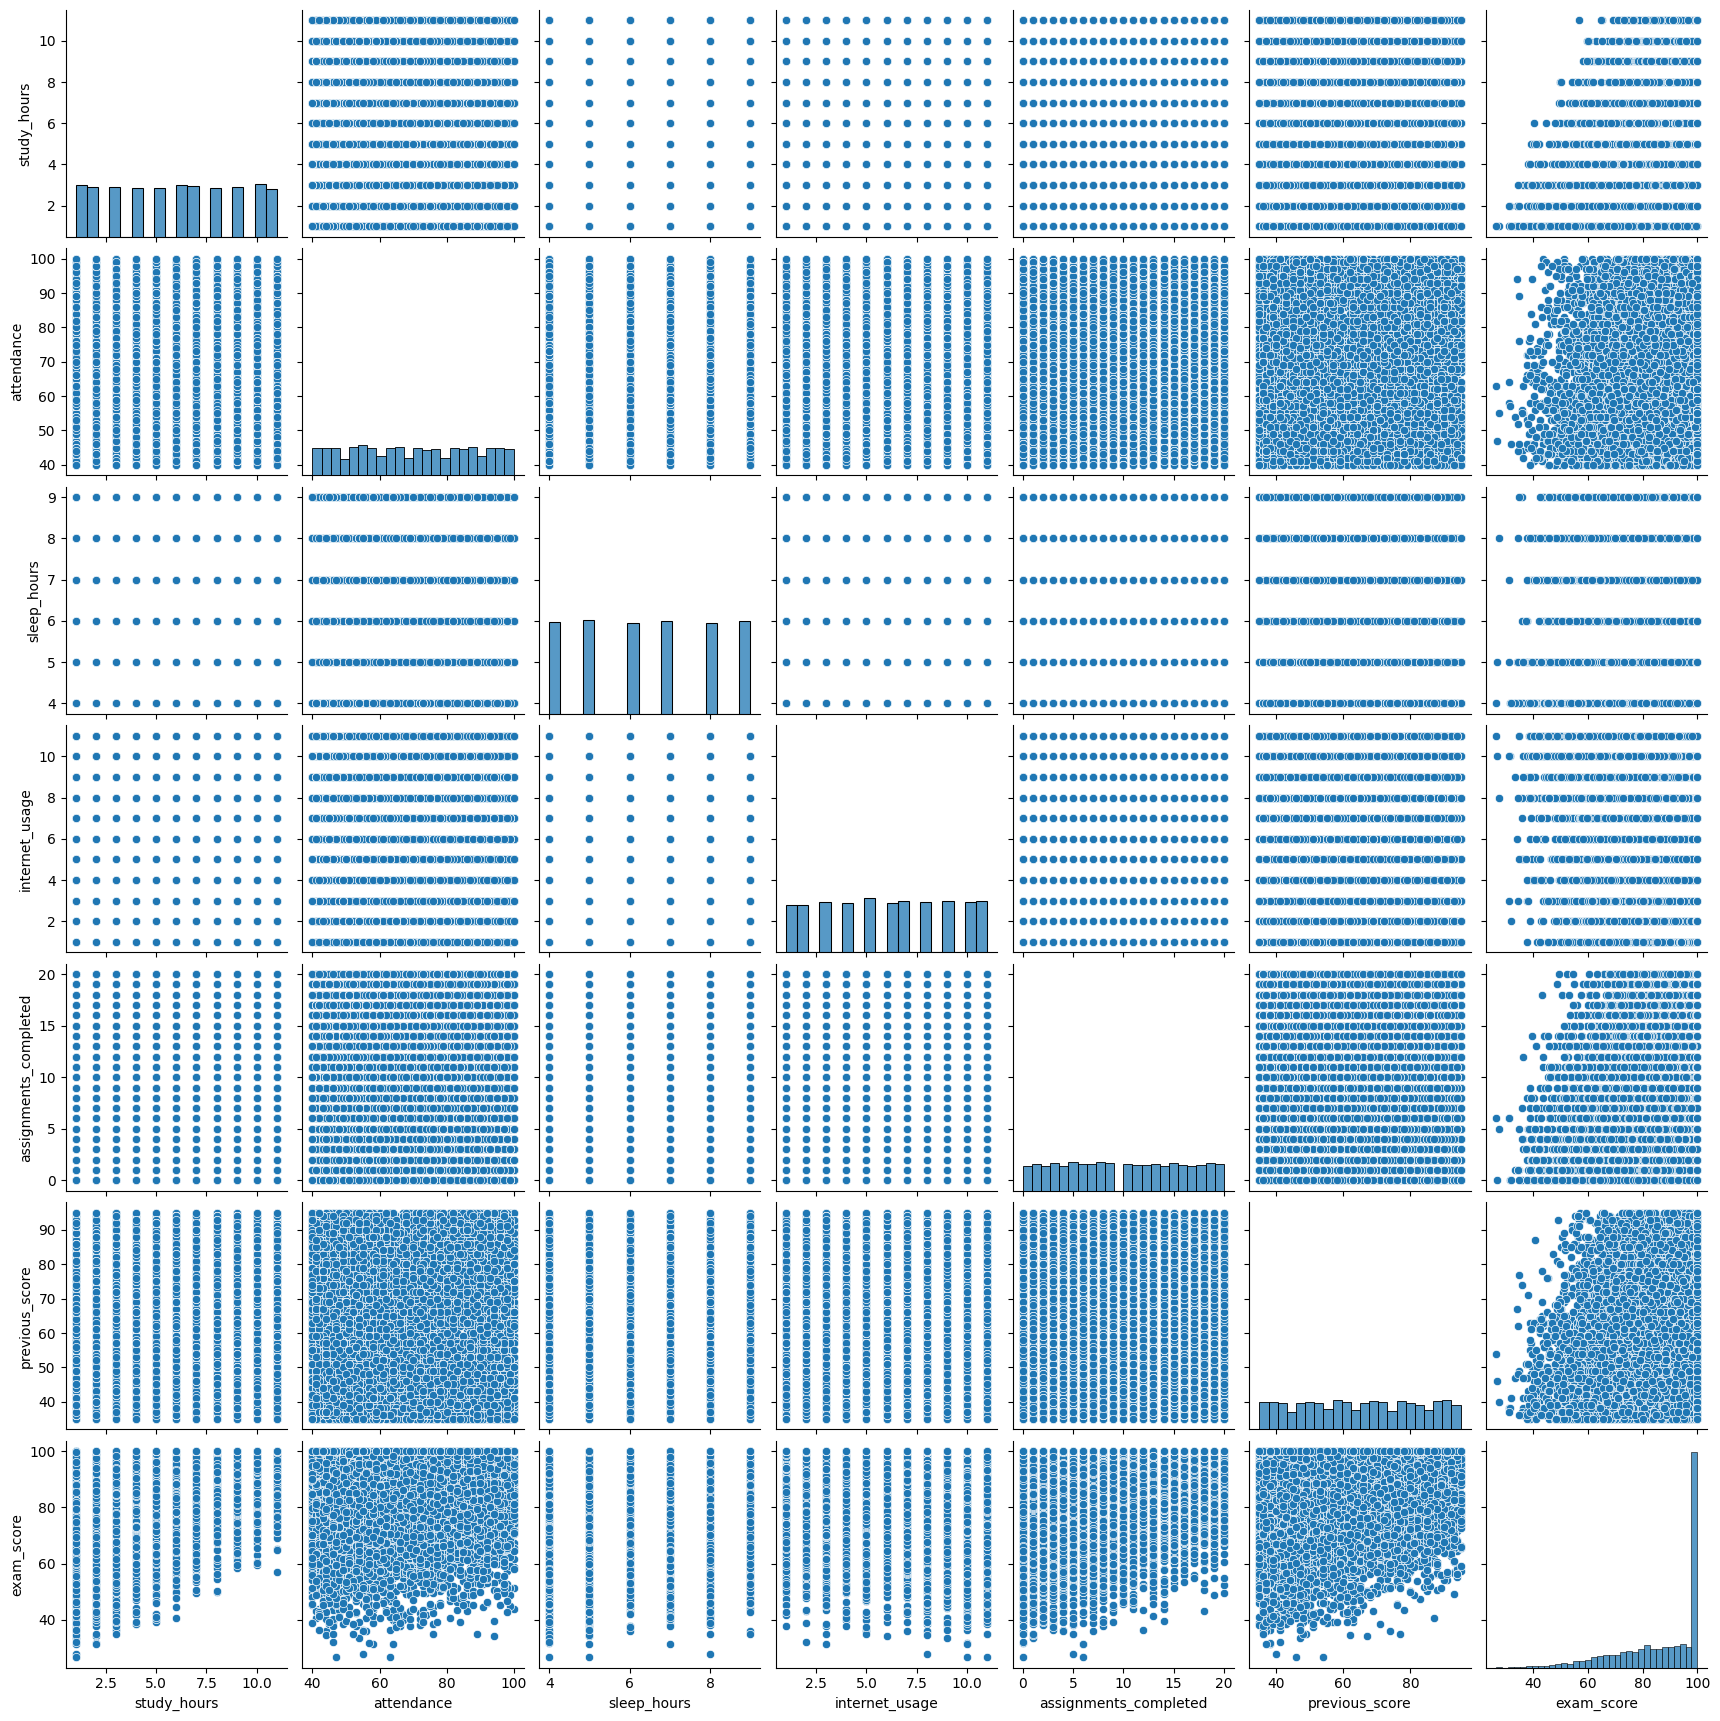

In [10]:
sns.pairplot(df)
plt.show()

From the above graphs we can see that there is some correlation between some of the columns lets dive further:

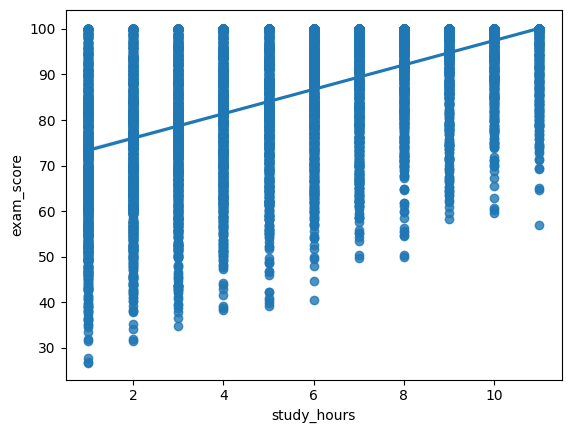

In [11]:
sns.regplot(x='study_hours',y='exam_score', data=df)
plt.show()

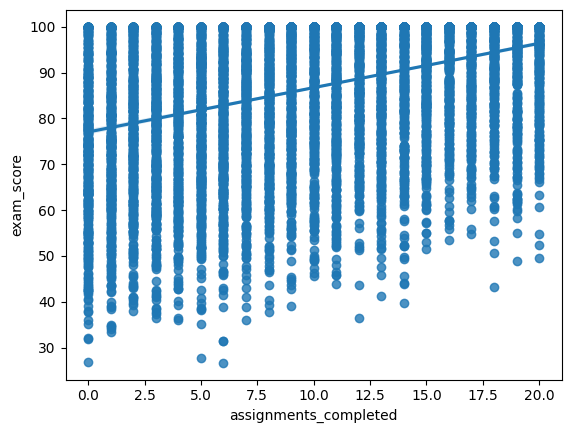

In [13]:
sns.regplot(x='assignments_completed',y='exam_score', data=df)
plt.show()

## Train and Test Split 

In [17]:
X = df[['assignments_completed','study_hours']]
y = df[['exam_score']]

X_train, X_test, Y_train, Y_test =  train_test_split(X, y,test_size=0.2)

print(f"X_train Shape:{X_train.shape}")
print(f"X_test Shape:{X_test.shape}")
print(f"Y_train Shape:{Y_train.shape}")
print(f"Y_test Shape:{Y_test.shape}")

X_train Shape:(8000, 2)
X_test Shape:(2000, 2)
Y_train Shape:(8000, 1)
Y_test Shape:(2000, 1)


## Model fit and metrics calculation

In [18]:
model  = LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

RSquare = model.score(X_test,Y_test)
print("The R-Squared for this :",RSquare)

The R-Squared for this : 0.48687090378912334


In [25]:
root_mean_squared_error(Y_test,y_pred)

10.919209247363446